In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import yfinance as yf
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel('data/serie_cafe_cepea_att_mar_26.xlsx')
df.rename(columns = {
    'Data': 'date',
    'À vista R$': 'price_brl',
    'À vista US$': 'price_usd'
}, inplace = True)
df['date'] = pd.to_datetime(df['date'])

df['Day'] = df['date'].dt.day
df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year


In [3]:
def fetch_bcb_series(series_id=433, start=None, end=None):
    """
    Busca série do SGS (BCB) e retorna DataFrame com índice datetime e coluna 'value'.
    start/end aceitam strings ISO (yyyy-mm-dd) ou objetos datetime-like.
    """
    base = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{series_id}/dados"
    params = ["formato=json"]
    if start is not None:
        params.append(f"dataInicial={pd.to_datetime(start).strftime('%d/%m/%Y')}")
    if end is not None:
        params.append(f"dataFinal={pd.to_datetime(end).strftime('%d/%m/%Y')}")
    url = base + "?" + "&".join(params)

    df_bcb = pd.read_json(url)
    df_bcb = df_bcb.rename(columns={"data": "date", "valor": "value"})
    df_bcb["date"] = pd.to_datetime(df_bcb["date"], format="%d/%m/%Y")
    df_bcb["value"] = df_bcb["value"].astype(str).str.replace(",", ".").astype(float)
    df_bcb = df_bcb.set_index("date")
    return df_bcb


bcb_series = {
    3698: "Taxa de câmbio média mensal (USD/BRL)",
    432: "Selic efetiva mensal",
    433: "IPCA mensal",
    11428: "IGP-M mensal",
    24363: "IBC-Br dessazonalizado",
    24364: "PIB mensal (IBC-Br)",
    21859: "Produção industrial geral",
    20683: "Crédito total sistema financeiro",
    22707: "Exportações totais",
    22708: "Importações totais",
}

# Fetch all series and create a dictionary with shorter names
bcb_data = {}
for series_id, description in bcb_series.items():
    try:
        df_series = fetch_bcb_series(series_id)
        bcb_data[series_id] = df_series
    except Exception as e:
        print(f"Erro ao buscar série {series_id}: {e}")

# Create a combined dataframe with intuitive column names
bcb_df = pd.DataFrame()
for series_id, description in bcb_series.items():
    if series_id in bcb_data:
        col_name = description.split("(")[0].strip().lower().replace(" ", "_")
        bcb_df[col_name] = bcb_data[series_id]["value"]

bcb_df = bcb_df.reset_index()
bcb_df.rename(columns={"date": "data"}, inplace=True)

Erro ao buscar série 432: File https://api.bcb.gov.br/dados/serie/bcdata.sgs.432/dados?formato=json does not exist
Erro ao buscar série 22707: Expected object or value


In [4]:
import requests

estacoes = requests.get("https://apitempo.inmet.gov.br/estacoes/T").json()
df_estacoes = pd.DataFrame(estacoes)


# print(df_estacoes[['CD_ESTACAO', 'DC_NOME', 'SG_ESTADO']].head(20))

estacoes = df_estacoes[df_estacoes['SG_ESTADO'].isin(['MG', 'ES'])]
print(estacoes[['CD_ESTACAO', 'DC_NOME']])


    CD_ESTACAO                  DC_NOME
3         A657           AFONSO CLAUDIO
8         A549          AGUAS VERMELHAS
9         A534                  AIMORES
11        A617                   ALEGRE
14        A508                 ALMENARA
..         ...                      ...
644       A515                 VARGINHA
645       A633  VENDA NOVA DO IMIGRANTE
647       A510                   VICOSA
649       A634               VILA VELHA
651       A612                  VITORIA

[80 rows x 2 columns]


In [5]:
fx = yf.download("BRL=X", start="1996-01-01")
fx = fx[["Close"]]
fx.rename(columns={"Close": "usd_brl"}, inplace=True)
fx.columns = fx.columns.droplevel(0)
fx = fx.reset_index()

kc = yf.download("KC=F", start="1996-01-01")
kc = kc[["Close"]]
kc.rename(columns={"Close": "kc_price"}, inplace=True)
kc.columns = kc.columns.droplevel(0)
kc = kc.reset_index()

cambio_df = fx

cambio_df['Day'] = cambio_df['Date'].dt.day
cambio_df['Month'] = cambio_df['Date'].dt.month
cambio_df['Year'] = cambio_df['Date'].dt.year

last_cambio = cambio_df.loc[
    cambio_df.groupby(['Year', 'Month'])['Day'].transform('max')
    == cambio_df['Day']
]

kc_df = kc

kc_df['Day'] = kc_df['Date'].dt.day
kc_df['Month'] = kc_df['Date'].dt.month
kc_df['Year'] = kc_df['Date'].dt.year

last_kc = kc_df.loc[
    kc_df.groupby(['Year', 'Month'])['Day'].transform('max')
    == kc_df['Day']
]

# renomeia as colunas vindas do yfinance para o nome que vou usar
last_cambio = last_cambio.rename(columns={'BRL=X': 'usd_brl'})
last_kc     = last_kc.rename(columns={'KC=F' : 'kc_price'})   # agregação mensal de kc_df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [6]:
df_final = (
    df
    .merge(last_cambio[['Year', 'Month', 'usd_brl']],
           on=['Year', 'Month'], how='left')
    .merge(last_kc[['Year', 'Month', 'kc_price']],
           on=['Year', 'Month'], how='left')             
    .merge(bcb_df, left_on='date', right_on='data', how='left')
).drop(columns=['data'])


In [7]:
df_final["price_brl"] = df_final["price_brl"].replace(0, np.nan)
df_final["usd_brl"] = df_final["usd_brl"].replace(0, np.nan)

df_final["log_price_brl"] = np.log(df_final["price_brl"])
df_final["log_usd_brl"] = np.log(df_final["usd_brl"])


In [12]:
def create_dataset(df, horizon, n_lags):

    data = df.copy()

    data["target"] = data["log_price_brl"].shift(-horizon)

    feature_cols = [
        "log_price_brl",
        "log_usd_brl",
        "ipca_mensal",
        "kc_price", 
        "produção_industrial_geral",
        "importações_totais",
        "taxa_de_câmbio_média_mensal",
        "igp-m_mensal",
        "ibc-br_dessazonalizado",
        "pib_mensal"
    ]

    for col in feature_cols:
        for lag in range(1, n_lags + 1):
            data[f"{col}_lag{lag}"] = data[col].shift(lag)

    data = data.dropna()

    X = data.filter(like="_lag")
    y = data["target"]

    return X, y



In [13]:
def walk_forward_direct(df, horizon, n_lags, start_train_idx):

    forecasts = []
    actuals = []
    dates = []

    for t in range(start_train_idx, len(df) - horizon):

        train_df = df.iloc[:t].copy()

        X_train, y_train = create_dataset(train_df, horizon, n_lags)

        model = XGBRegressor(
            n_estimators=1000,
            max_depth=3,
            learning_rate=0.05
        )

        model.fit(X_train, y_train)

        pred_df = df.iloc[:t + 1].copy()
        X_all, _ = create_dataset(pred_df, horizon, n_lags)
        
        X_pred = X_all.iloc[[-1]]

        y_hat = model.predict(X_pred)[0]
        actual = df["log_price_brl"].iloc[t + horizon]

        forecasts.append(y_hat)
        actuals.append(actual)
        dates.append(df.index[t + horizon])

    return pd.DataFrame({
        "y_true": actuals,
        "y_pred": forecasts
    }, index=dates)

In [14]:
def forecast_metrics(df):
    rmse = np.sqrt(np.mean((df.y_true - df.y_pred) ** 2))
    mae = np.mean(np.abs(df.y_true - df.y_pred))
    mape = np.mean(np.abs((df.y_true - df.y_pred) / df.y_true)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

In [15]:
start_train_idx = df_final.set_index('date').index.searchsorted("2018-01-01")

for h in [1,3,6]:
    print(f"\nXGBoost Multivariado – horizonte {h}")
    results = walk_forward_direct(df_final, h, 6, start_train_idx)
    print(forecast_metrics(results))


XGBoost Multivariado – horizonte 1
{'RMSE': np.float64(0.1639138872955485), 'MAE': np.float64(0.13155531377041285), 'MAPE': np.float64(1.9027239351879863)}

XGBoost Multivariado – horizonte 3
{'RMSE': np.float64(0.28052532130606284), 'MAE': np.float64(0.21930547532225061), 'MAPE': np.float64(3.132200622773852)}

XGBoost Multivariado – horizonte 6
{'RMSE': np.float64(0.3468682884989161), 'MAE': np.float64(0.25768278406488315), 'MAPE': np.float64(3.666645735108355)}


KeyboardInterrupt: 

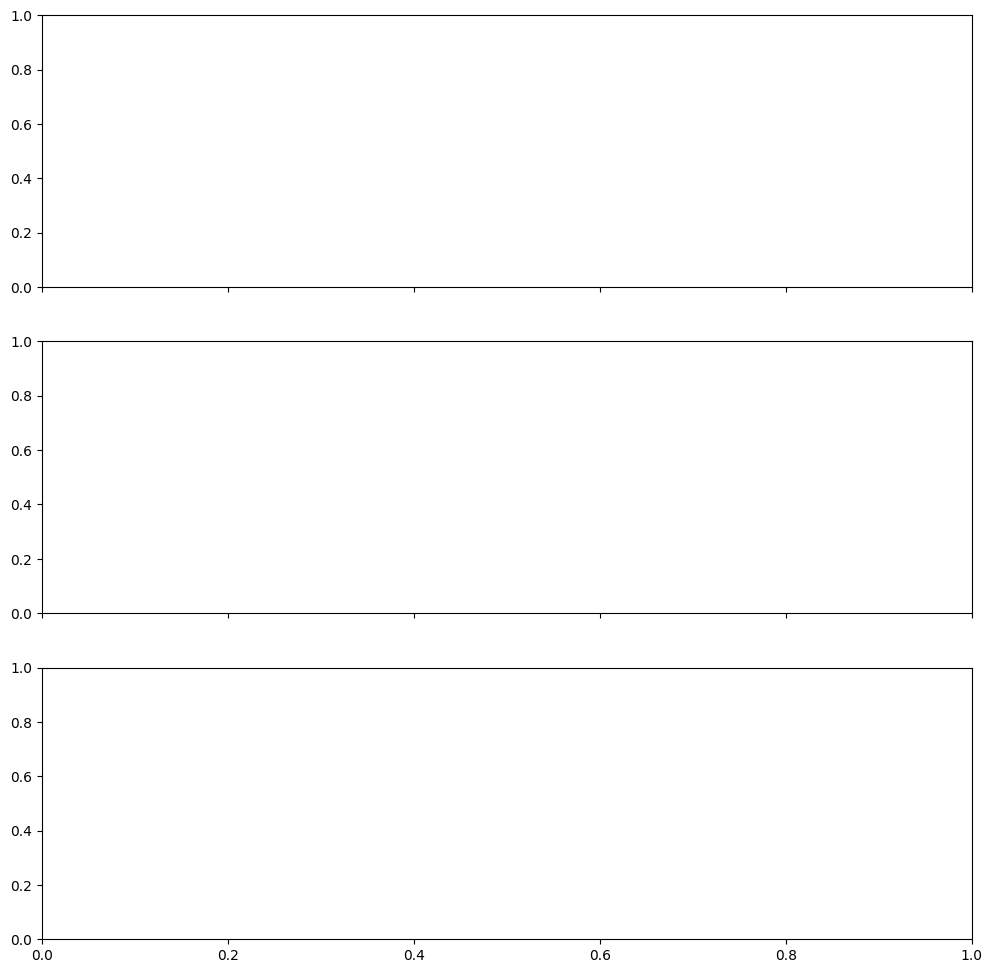

In [19]:
def plot_walk_forward_results(df, horizons, n_lags, start_train_idx):
    fig, axes = plt.subplots(len(horizons), 1, figsize=(12, 4 * len(horizons)), sharex=True)

    if len(horizons) == 1:
        axes = [axes]

    for ax, horizon in zip(axes, horizons):
        results = walk_forward_direct(df, horizon, n_lags, start_train_idx)

        y_true = np.exp(results["y_true"])
        y_pred = np.exp(results["y_pred"])

        ax.plot(y_true.index, y_true.values, color="steelblue", linewidth=2, label="Real")
        ax.plot(y_pred.index, y_pred.values, color="tomato", linewidth=1.5, linestyle="--", label="Previsto")

        ax.set_title(f"Horizonte h={horizon}", fontsize=11)
        ax.set_ylabel("Preço (R$)")
        ax.legend()
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Data")
    plt.suptitle("Walk-forward — Real vs Previsto", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

df_plot = df_final.set_index("date")

plot_walk_forward_results(df_plot, horizons=[1, 3, 6], n_lags=6, start_train_idx=start_train_idx)

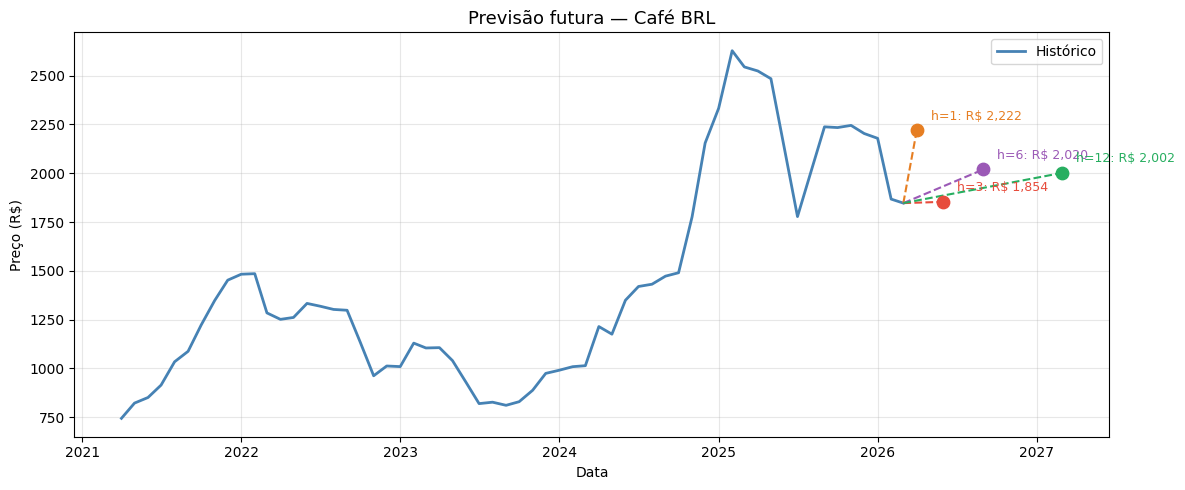

In [20]:
def forecast_future(df, horizon, n_lags):
    X_train, y_train = create_dataset(df.copy(), horizon, n_lags)

    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05)
    model.fit(X_train, y_train)

    # Monta X_pred com os mesmos nomes de colunas do X_train
    feature_cols = [
            "log_price_brl",
            "log_usd_brl",
            "ipca_mensal",
            "kc_price", 
            "produção_industrial_geral",
            "importações_totais",
            "taxa_de_câmbio_média_mensal",
            "igp-m_mensal",
            "ibc-br_dessazonalizado",
            "pib_mensal"
        ]
    row = {}
    for col in feature_cols:
        for lag in range(1, n_lags + 1):
            row[f"{col}_lag{lag}"] = df[col].iloc[-lag]

    X_pred = pd.DataFrame([row])[X_train.columns]  # garante mesma ordem

    y_hat = model.predict(X_pred)[0]

    last_date = df.index[-1]
    future_date = last_date + pd.DateOffset(months=horizon)

    return future_date, np.exp(y_hat)


def plot_future_forecasts(df, horizons, n_lags, n_history=60):
    fig, ax = plt.subplots(figsize=(12, 5))

    hist = np.exp(df["log_price_brl"].iloc[-n_history:])
    ax.plot(hist.index, hist.values, color="steelblue", linewidth=2, label="Histórico")

    last_date = df.index[-1]
    last_value = np.exp(df["log_price_brl"].iloc[-1])

    colors = ["#e67e22", "#e74c3c", "#9b59b6", "#27ae60"]  # laranja, vermelho, roxo, verde

    offsets = [(10, 10), (10, 10), (10, 10), (10, 10)]  # adiciona offset pro h=12

    for (horizon, color), offset in zip(zip(horizons, colors), offsets):
        future_date, future_value = forecast_future(df, horizon, n_lags)

        ax.plot(
            [last_date, future_date],
            [last_value, future_value],
            linestyle="--", color=color, linewidth=1.5
        )

        ax.scatter(future_date, future_value, color=color, s=80, zorder=5)

        ax.annotate(
            f"h={horizon}: R$ {future_value:,.0f}",
            xy=(future_date, future_value),
            xytext=offset, textcoords="offset points",
            color=color, fontsize=9, va="center"
        )

    ax.set_title("Previsão futura — Café BRL", fontsize=13)
    ax.set_xlabel("Data")
    ax.set_ylabel("Preço (R$)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ✅ Seta o índice como datetime antes de chamar
df_plot = df_final.set_index("date")

plot_future_forecasts(df_plot, horizons=[1, 3, 6, 12], n_lags=12)

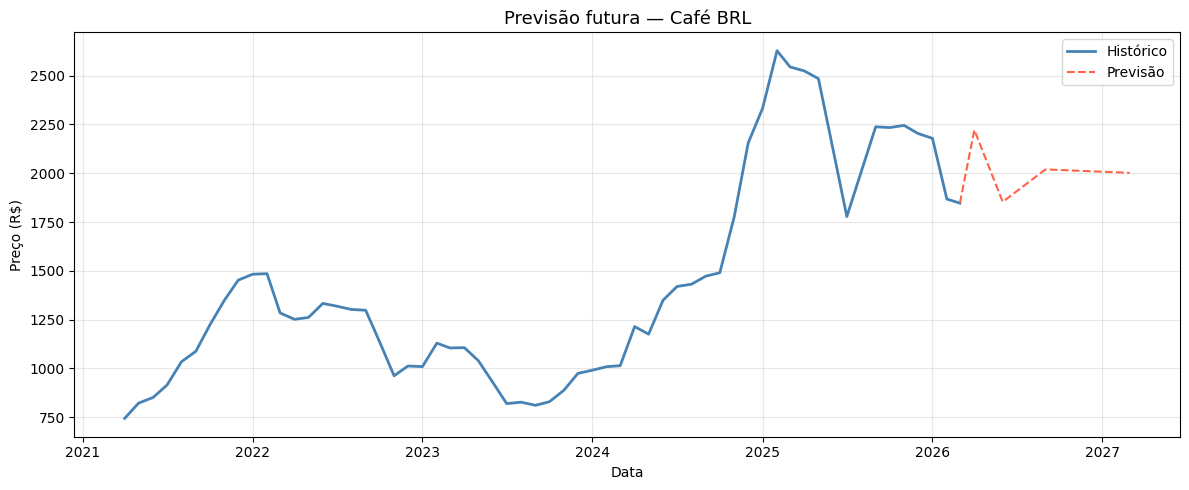

In [25]:
def plot_future_forecasts(df, horizons, n_lags, n_history=60):
    fig, ax = plt.subplots(figsize=(12, 5))

    hist = np.exp(df["log_price_brl"].iloc[-n_history:])
    ax.plot(hist.index, hist.values, color="steelblue", linewidth=2, label="Histórico")

    last_date = df.index[-1]
    last_value = np.exp(df["log_price_brl"].iloc[-1])

    future_dates = [last_date]
    future_values = [last_value]

    for horizon in horizons:
        future_date, future_value = forecast_future(df, horizon, n_lags)
        future_dates.append(future_date)
        future_values.append(future_value)

    ax.plot(future_dates, future_values, linestyle="--", color="tomato", linewidth=1.5, label="Previsão")

    ax.set_title("Previsão futura — Café BRL", fontsize=13)
    ax.set_xlabel("Data")
    ax.set_ylabel("Preço (R$)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ✅ Seta o índice como datetime antes de chamar
df_plot = df_final.set_index("date")

plot_future_forecasts(df_plot, horizons=[1, 3, 6, 12], n_lags=12)